-----
# **PRÁCTICA DE TRANSFORMER**
-----

**Autores: Junjing Wu , Yixuan Lu y Xianye Lin**

En esta práctica vamos a explorar el uso de la arquitectura Transformer aplicada a la predicción de secuencias numéricas y series temporales. Para comprender su funcionamiento y evaluar su rendimiento, llevaremos a cabo los siguientes dos ejercicios:

1. **Predicción de datos sintéticos:** Comenzaremos entrenando un modelo Transformer con los datos de una onda simple (la función seno) con el objetivo de predecir los 50 valores subsiguientes. Esto nos servirá como prueba de concepto para validar la arquitectura.
2. **Aplicación en un entorno real (Finanzas):** Una vez validado el modelo, daremos un paso más complejo entrenando un Transformer con el histórico del precio de cierre diario de las acciones de Apple (AAPL), para intentar predecir sus próximos 50 valores y analizar las métricas de error.


## 1. Predicción de la función seno con un Transformer

##### Crea los datos de la función seno

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Crear la onda seno
t = np.linspace(0, 100, 1000) # 1000 puntos de 0 a 100
data = np.sin(t).reshape(-1, 1)

# Función para crear ventanas (Secuencias)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 50 
X, y = create_sequences(data, seq_length)

# Convertir a Tensores
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') para nvidia
#device = torch.device('mps' if torch.mps.is_available() else 'cpu') para macos
def set_device():
    if torch.backends.mps.is_available():
        dev = torch.device("mps")
    elif torch.cuda.is_available():
        dev = torch.device("cuda")
    else:
        dev = torch.device("cpu")
    print(f"Using {dev} device")
    return dev
device = set_device()
print(device)
X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

mps


##### Define la red completa

### Arquitectura del modelo

El modelo implementa un Transformer para series temporales.

Componentes principales:
- Embedding lineal de la entrada
- Encoder Transformer con múltiples cabezas de atención
- Capa lineal final para predecir el siguiente valor

El modelo recibe una secuencia de valores y aprende a predecir
el siguiente valor de la serie.

In [ ]:
class SequenceTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=8):
        super(SequenceTransformer, self).__init__()
        
        # Proyección: Pasa el valor único de la onda a un vector de 64 dimensiones
        self.input_proj = nn.Linear(1, d_model)

        # Positional encoding sinusoidal: Le dice al modelo el orden del tiempo
        pe = torch.zeros(seq_length, d_model)
        pos = torch.arange(0, seq_length).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        # register_buffer guarda esto en la memoria gráfica pero sin que se entrene (es fijo)
        self.register_buffer('pe', pe.unsqueeze(0))

        #Capa del Transformer: dropout=0.0 porque la función seno es matemática pura (sin ruido)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256,
            dropout=0.0, batch_first=True 
        )
        # Apilamos 4 capas para que entienda bien la curva
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)
        
        #Decodificador: estabiliza los valores y los reduce de nuevo a 1 solo número (predicción)
        self.layer_norm = nn.LayerNorm(d_model)
        self.fc_out = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(), # Activación moderna y suave
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)                  # Expandir dimensión
        x = x + self.pe[:, :x.size(1), :]       # Añadir la "huella del tiempo"
        x = self.transformer_encoder(x)         # Procesar toda la secuencia a la vez
        
        # Extraer solo el último instante de tiempo (x[:, -1, :]) y normalizarlo
        x = self.layer_norm(x[:, -1, :])        
        
        x = self.fc_out(x)                      # Predecir el siguiente punto
        return x

model = SequenceTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss() # El Error Cuadrático Medio es perfecto para curvas matemáticas
model

SequenceTransformer(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (fc_out): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear

##### Entrena

In [44]:
epochs = 400
batch_size = 64

dataset = torch.utils.data.TensorDataset(X, y)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(dataset)
    scheduler.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}  Loss: {epoch_loss:.8f}")

Epoch 50/400  Loss: 0.00000396
Epoch 100/400  Loss: 0.00000135
Epoch 150/400  Loss: 0.00000102
Epoch 200/400  Loss: 0.00000005
Epoch 250/400  Loss: 0.00000002
Epoch 300/400  Loss: 0.00000000
Epoch 350/400  Loss: 0.00000000
Epoch 400/400  Loss: 0.00000000


##### Calcula los puntos siguientes

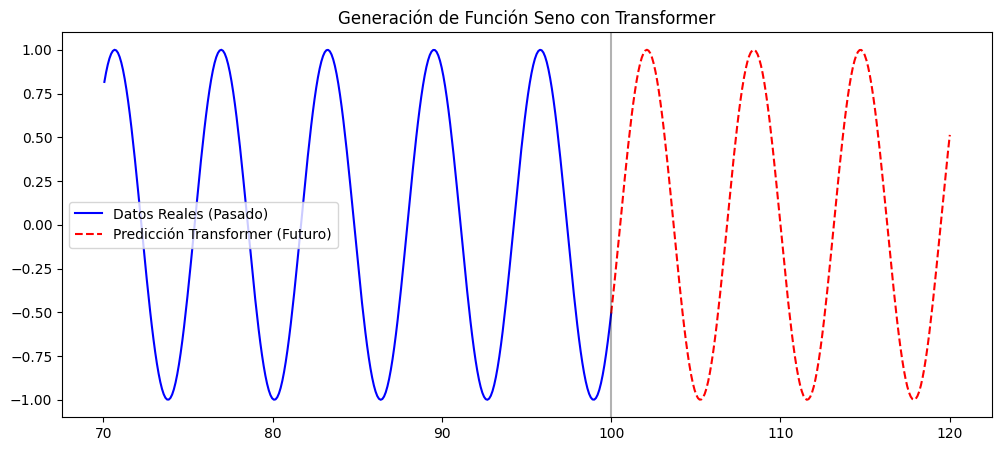

In [45]:
model.eval()
future_points = 200
predictions = []

# Tomamos la última ventana de los datos reales para empezar
last_sequence = X[-1].unsqueeze(0) 

for _ in range(future_points):
    with torch.no_grad():
        pred = model(last_sequence) # Predice el siguiente punto
        predictions.append(pred.item())
        
        # Actualizamos la ventana: desplazamos y añadimos la predicción
        new_row = pred.unsqueeze(1) 
        last_sequence = torch.cat((last_sequence[:, 1:, :], new_row), dim=1)

# Pintar resultados
plt.figure(figsize=(12,5))
plt.plot(t[-300:], data[-300:], label="Datos Reales (Pasado)", color="blue")
plt.plot(np.linspace(t[-1], t[-1]+20, future_points), predictions, label="Predicción Transformer (Futuro)", linestyle="--", color="red")
plt.axvline(x=t[-1], color='black', alpha=0.3)
plt.legend()
plt.title("Generación de Función Seno con Transformer")
plt.show()

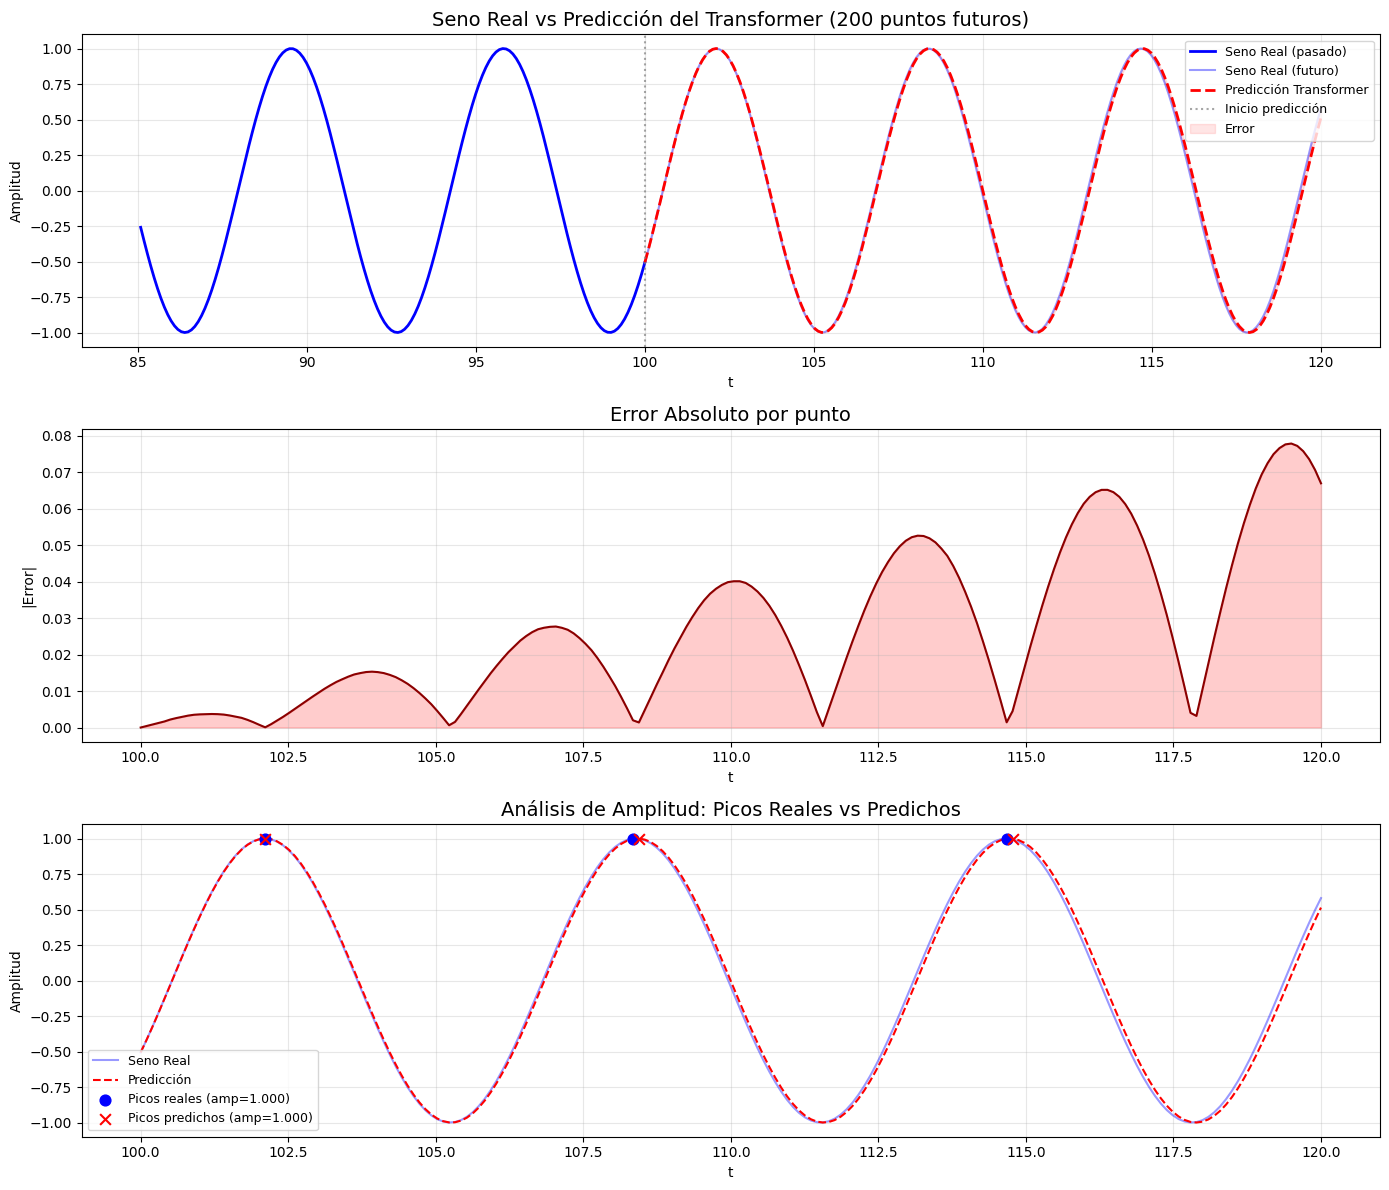

In [ ]:
# Gráfica detallada: Seno real vs predicción 

# Generar el seno real para el rango futuro
t_future = np.linspace(t[-1], t[-1] + 20, future_points)
real_future = np.sin(t_future)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Gráfica 1: Vista general con zoom en la transición 
ax1 = axes[0]
ax1.plot(t[-150:], data[-150:].flatten(), label='Seno Real (pasado)', color='blue', linewidth=2)
ax1.plot(t_future, real_future, label='Seno Real (futuro)', color='blue', linewidth=1.5, alpha=0.4)
ax1.plot(t_future, predictions, label='Predicción Transformer', color='red', linewidth=2, linestyle='--')
ax1.axvline(x=t[-1], color='gray', linestyle=':', alpha=0.7, label='Inicio predicción')
ax1.fill_between(t_future, real_future, predictions, color='red', alpha=0.1, label='Error')
ax1.set_title('Seno Real vs Predicción del Transformer (200 puntos futuros)', fontsize=14)
ax1.set_ylabel('Amplitud')
ax1.set_xlabel('t')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Gráfica 2: Error absoluto punto a punto 
ax2 = axes[1]
errors = np.abs(np.array(predictions) - real_future)
ax2.plot(t_future, errors, color='darkred', linewidth=1.5)
ax2.fill_between(t_future, 0, errors, color='red', alpha=0.2)
ax2.set_title('Error Absoluto por punto', fontsize=14)
ax2.set_ylabel('|Error|')
ax2.set_xlabel('t')
ax2.grid(True, alpha=0.3)

# Gráfica 3: Degradación de amplitud 
ax3 = axes[2]
# Amplitud real vs predicha (picos)
from scipy.signal import find_peaks
pred_array = np.array(predictions)
peaks_real, _ = find_peaks(real_future, height=0.5)
peaks_pred, _ = find_peaks(pred_array, height=0.3)

ax3.plot(t_future, real_future, label='Seno Real', color='blue', alpha=0.4, linewidth=1.5)
ax3.plot(t_future, pred_array, label='Predicción', color='red', linewidth=1.5, linestyle='--')

if len(peaks_real) > 0:
    ax3.scatter(t_future[peaks_real], real_future[peaks_real], color='blue', s=60, zorder=5, label=f'Picos reales (amp={np.mean(real_future[peaks_real]):.3f})')
if len(peaks_pred) > 0:
    ax3.scatter(t_future[peaks_pred], pred_array[peaks_pred], color='red', s=60, zorder=5, marker='x', label=f'Picos predichos (amp={np.mean(pred_array[peaks_pred]):.3f})')

ax3.set_title('Análisis de Amplitud: Picos Reales vs Predichos', fontsize=14)
ax3.set_ylabel('Amplitud')
ax3.set_xlabel('t')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* ### Comparación: Seno Real vs Predicción del Transformer

La gráfica muestra cómo el modelo Transformer predice valores futuros de la función seno a partir de datos pasados.  
Se observa que la predicción sigue correctamente el patrón periódico de la señal real, aunque aparece una ligera desviación conforme avanza la predicción en el tiempo.



* ### Error absoluto por punto

Esta gráfica representa el error absoluto entre los valores reales y los predichos.  
El error es inicialmente muy bajo, pero aumenta progresivamente a medida que el modelo predice más puntos hacia el futuro, lo cual es normal debido a la acumulación de errores en predicciones autoregresivas.



* ### Análisis de amplitud: picos reales vs predichos

En esta gráfica se comparan los picos de la señal real con los picos de la señal predicha.  
El modelo logra reproducir correctamente la amplitud y la posición de los máximos, lo que indica que ha aprendido adecuadamente el patrón periódico de la función seno.

In [ ]:
# Métricas de evaluación: Seno
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

pred_array = np.array(predictions)
t_future = np.linspace(t[-1], t[-1] + 20, future_points)
real_future = np.sin(t_future)

mae = mean_absolute_error(real_future, pred_array)
mse = mean_squared_error(real_future, pred_array)
rmse = np.sqrt(mse)
r2 = r2_score(real_future, pred_array)
max_err = np.max(np.abs(real_future - pred_array))

# Correlación de Pearson
correlation = np.corrcoef(real_future, pred_array)[0, 1]

# Degradación de amplitud
amp_real = np.mean(real_future[peaks_real]) if len(peaks_real) > 0 else float('nan')
amp_pred = np.mean(pred_array[peaks_pred]) if len(peaks_pred) > 0 else float('nan')
amp_loss = ((amp_real - amp_pred) / amp_real * 100) if amp_real > 0 else float('nan')

metrics = {
    'Métrica': [
        'MAE (Mean Absolute Error)',
        'MSE (Mean Squared Error)',
        'RMSE (Root Mean Squared Error)',
        'R² (Coeficiente de Determinación)',
        'Max Error (Error Máximo)',
        'Correlación de Pearson',
        'Pérdida de Amplitud'
    ],
    'Valor': [
        f"{mae:.6f}",
        f"{mse:.6f}",
        f"{rmse:.6f}",
        f"{r2:.6f}",
        f"{max_err:.6f}",
        f"{correlation:.6f}",
        f"{amp_loss:.2f}%"
    ],
    'Interpretación': [
        'Error promedio por punto (0 = perfecto)',
        'Penaliza errores grandes',
        'Error típico (misma escala que MAE)',
        '1.0 = perfecto, 0 = como predecir la media',
        'Peor predicción individual',
        '1.0 = correlación perfecta',
        'Cuánto se reduce la amplitud predicha vs real'
    ]
}

df_metrics = pd.DataFrame(metrics)


print("   Métricas de evaluación — Transformer Función Seno")

for _, row in df_metrics.iterrows():
    print(f"\n  {row['Métrica']}")
    print(f"    → {row['Valor']}  ({row['Interpretación']})")


   MÉTRICAS DE EVALUACIÓN — Transformer Función Seno

  MAE (Mean Absolute Error)
    → 0.026262  (Error promedio por punto (0 = perfecto))

  MSE (Mean Squared Error)
    → 0.001150  (Penaliza errores grandes)

  RMSE (Root Mean Squared Error)
    → 0.033909  (Error típico (misma escala que MAE))

  R² (Coeficiente de Determinación)
    → 0.997587  (1.0 = perfecto, 0 = como predecir la media)

  Max Error (Error Máximo)
    → 0.077854  (Peor predicción individual)

  Correlación de Pearson
    → 0.998800  (1.0 = correlación perfecta)

  Pérdida de Amplitud
    → 0.01%  (Cuánto se reduce la amplitud predicha vs real)




**Las métricas obtenidas muestran que el modelo logra una predicción muy precisa de la función seno.**



## Predicción de las acciones de Apple

In [ ]:
# %pip install --upgrade yfinance

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Configuración de dispositivo (GPU si está disponible)
device = torch.device('mps' if torch.mps.is_available() else 'cpu')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [49]:
# Descargar datos
df = yf.download('AAPL', start='2020-01-01', end='2026-01-01')
data = df['Close'].values.reshape(-1, 1)

# Normalización (Importante para Transformers)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Función para crear secuencias
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 60 # Usamos 60 días previos para predecir el siguiente
X, y = create_sequences(data_scaled, seq_length)

# Convertir a Tensores de PyTorch
X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

print(f"Forma de X: {X.shape}") # [muestras, seq_length, 1]

[*********************100%***********************]  1 of 1 completed

Forma de X: torch.Size([1448, 60, 1])


In [ ]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super(TimeSeriesTransformer, self).__init__()

        # Dimensión interna del modelo 
        self.d_model = d_model

        self.input_proj = nn.Linear(input_size, d_model)

        # Positional encoding sinusoidal para introducir información temporal
        # Permite al Transformer conocer la posición de cada elemento en la secuencia
        pe = torch.zeros(5000, d_model)  # soporta secuencias de hasta 5000 pasos
        pos = torch.arange(0, 5000).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        # Se guarda como buffer para que no se entrene pero sí se mueva con el modelo
        self.register_buffer('pe', pe.unsqueeze(0))

        # Capa base del encoder Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,       # dimensión del embedding
            nhead=nhead,           # número de cabezas de atención
            dim_feedforward=256,   # tamaño de la red feedforward interna
            dropout=dropout,
            batch_first=True       # formato de entrada: [batch, seq, features]
        )

        # Encoder compuesto por varias capas Transformer
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Normalización para estabilizar el entrenamiento
        self.layer_norm = nn.LayerNorm(d_model)

        # Red final para producir la predicción
        self.fc_out = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)   # salida: siguiente valor de la serie temporal
        )

    def forward(self, x):  

        x = self.input_proj(x)
        x = x + self.pe[:, :x.size(1), :]

        x = self.transformer_encoder(x)
        x = self.layer_norm(x[:, -1, :])

        x = self.fc_out(x)

        return x


# Inicialización del modelo y envío al dispositivo (CPU/GPU)
model = TimeSeriesTransformer().to(device)

criterion = nn.MSELoss()

# Optimizador Adam para actualizar los pesos del modelo
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [51]:
# entrena
epochs = 300
batch_size = 64

dataset = torch.utils.data.TensorDataset(X, y)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

model.train()
last_lr = optimizer.param_groups[0]['lr']
for epoch in range(epochs):
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(dataset)
    scheduler.step(epoch_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    if current_lr != last_lr:
        print(f"  -> LR reducido a {current_lr:.6f}")
        last_lr = current_lr
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1}/{epochs}  Loss: {epoch_loss:.6f}")

Epoch 30/300  Loss: 0.000386
Epoch 60/300  Loss: 0.000288
  -> LR reducido a 0.000500
Epoch 90/300  Loss: 0.000261
  -> LR reducido a 0.000250
Epoch 120/300  Loss: 0.000219
  -> LR reducido a 0.000125
Epoch 150/300  Loss: 0.000200
  -> LR reducido a 0.000063
Epoch 180/300  Loss: 0.000216
  -> LR reducido a 0.000031
  -> LR reducido a 0.000016
Epoch 210/300  Loss: 0.000195
  -> LR reducido a 0.000008
  -> LR reducido a 0.000004
Epoch 240/300  Loss: 0.000191
  -> LR reducido a 0.000002
Epoch 270/300  Loss: 0.000196
  -> LR reducido a 0.000001
  -> LR reducido a 0.000000
Epoch 300/300  Loss: 0.000196


In [ ]:
model.eval()
future_predictions = []
current_batch = X[-1].unsqueeze(0) # Tomamos la última secuencia conocida

for _ in range(50):
    with torch.no_grad():
        pred = model(current_batch)
        future_predictions.append(pred.item())
        
        # Actualizar la ventana: quitar el primero, añadir la predicción al final
        new_pred = pred.unsqueeze(1) # [1, 1, 1]
        current_batch = torch.cat((current_batch[:, 1:, :], new_pred), dim=1)

# Desnormalizar los resultados
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

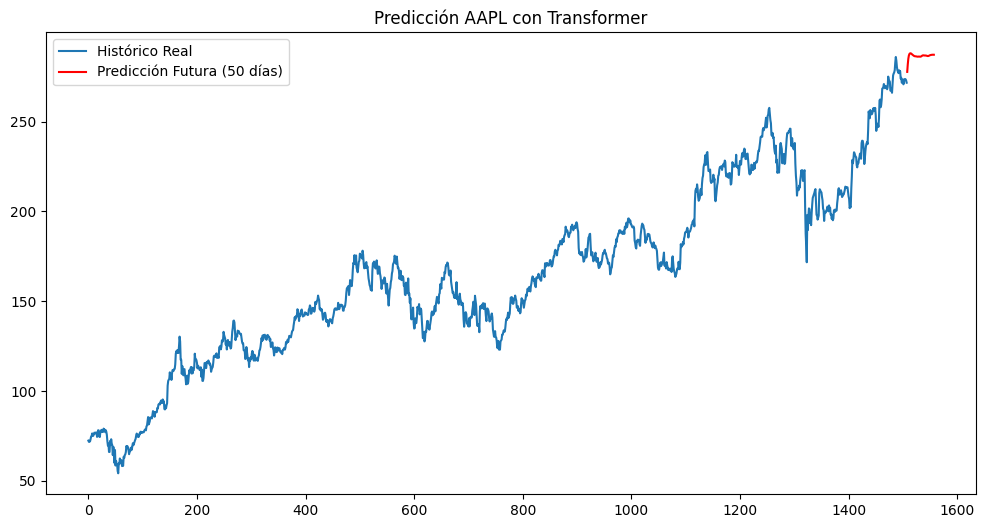

In [53]:
plt.figure(figsize=(12,6))
plt.plot(range(len(data)), scaler.inverse_transform(data_scaled), label='Histórico Real')
plt.plot(range(len(data), len(data) + 50), future_predictions, label='Predicción Futura (50 días)', color='red')
plt.title('Predicción AAPL con Transformer')
plt.legend()
plt.show()

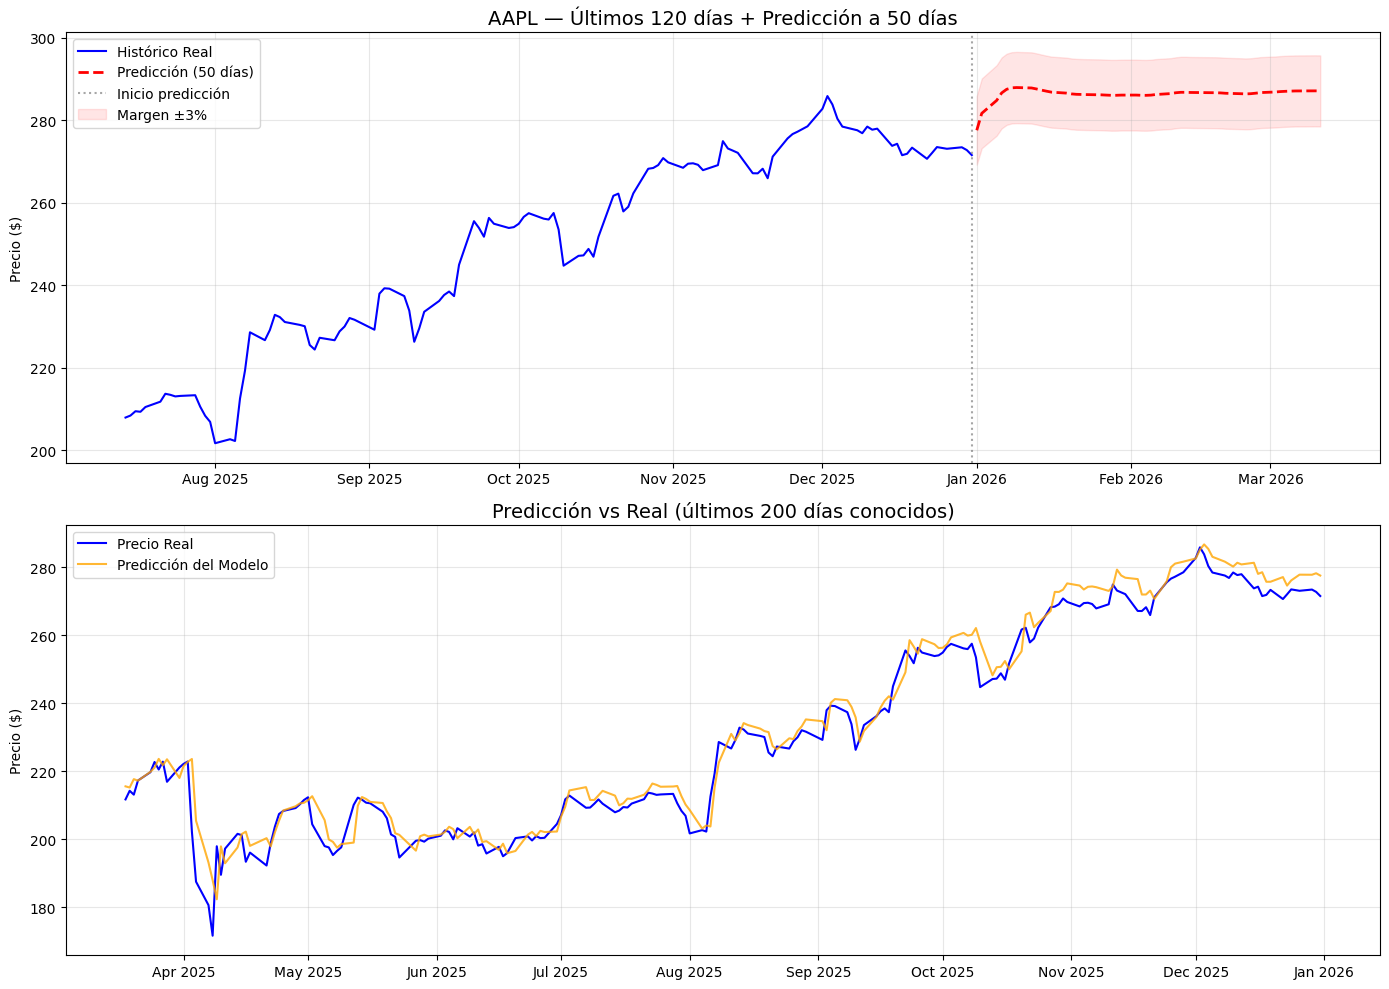

In [54]:
# Gráfica detallada: zoom en los últimos días + predicción 

import matplotlib.dates as mdates

# Fechas reales del histórico
dates_real = df.index[-120:]  # últimos 120 días
prices_real = scaler.inverse_transform(data_scaled)[-120:]

# Fechas futuras (50 días hábiles a partir del último dato)
last_date = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=50)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfica 1: Zoom últimos 120 días + predicción
ax1 = axes[0]
ax1.plot(dates_real, prices_real, label='Histórico Real', color='blue', linewidth=1.5)
ax1.plot(future_dates, future_predictions, label='Predicción (50 días)', color='red', linewidth=2, linestyle='--')
ax1.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Inicio predicción')

# Zona sombreada de predicción
ax1.fill_between(future_dates, 
                 future_predictions.flatten() * 0.97, 
                 future_predictions.flatten() * 1.03, 
                 color='red', alpha=0.1, label='Margen ±3%')

ax1.set_title('AAPL — Últimos 120 días + Predicción a 50 días', fontsize=14)
ax1.set_ylabel('Precio ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Gráfica 2: Predicción del modelo sobre datos conocidos 
ax2 = axes[1]

# Generar predicciones sobre los últimos 200 datos conocidos para comparar
model.eval()
backtest_preds = []
with torch.no_grad():
    for i in range(max(0, len(X) - 200), len(X)):
        pred = model(X[i].unsqueeze(0))
        backtest_preds.append(pred.item())

backtest_real = scaler.inverse_transform(data_scaled[-(len(backtest_preds)):])
backtest_pred_inv = scaler.inverse_transform(np.array(backtest_preds).reshape(-1, 1))
backtest_dates = df.index[-(len(backtest_preds)):]

ax2.plot(backtest_dates, backtest_real, label='Precio Real', color='blue', linewidth=1.5)
ax2.plot(backtest_dates, backtest_pred_inv, label='Predicción del Modelo', color='orange', linewidth=1.5, alpha=0.8)
ax2.set_title('Predicción vs Real (últimos 200 días conocidos)', fontsize=14)
ax2.set_ylabel('Precio ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

+ ### Predicción del precio de AAPL (50 días futuros)

La primera gráfica muestra el precio histórico reciente de la acción de Apple y la predicción generada por el modelo para los próximos 50 días.  
La línea azul representa los datos reales históricos, mientras que la línea roja discontinua muestra la predicción del modelo. La línea vertical indica el punto donde comienzan las predicciones. El área sombreada representa un margen de incertidumbre aproximado de ±3%. El modelo proyecta una evolución relativamente estable del precio tras el último dato observado.


+ ### Comparación entre precio real y predicción del modelo

La segunda gráfica compara el precio real con la predicción del modelo en los últimos 200 días conocidos.  
Se observa que la predicción sigue bastante bien la tendencia general del precio real, capturando subidas y bajadas principales del mercado. Aunque existen pequeñas diferencias en algunos puntos, el modelo logra aproximar correctamente la dinámica general de la serie temporal.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generar predicciones sobre todos los datos conocidos 
model.eval()
all_preds = []
with torch.no_grad():
    for i in range(len(X)):
        pred = model(X[i].unsqueeze(0))
        all_preds.append(pred.item())

# Desnormalizar
all_preds_inv = scaler.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
all_real_inv = scaler.inverse_transform(data_scaled[seq_length:]).flatten()

# Calcular métricas 
mae = mean_absolute_error(all_real_inv, all_preds_inv)
mse = mean_squared_error(all_real_inv, all_preds_inv)
rmse = np.sqrt(mse)
r2 = r2_score(all_real_inv, all_preds_inv)
smape = np.mean(2 * np.abs(all_real_inv - all_preds_inv) / (np.abs(all_real_inv) + np.abs(all_preds_inv))) * 100
max_err = np.max(np.abs(all_real_inv - all_preds_inv))

# Dirección correcta (si sube/baja coincide)
real_dir = np.diff(all_real_inv) > 0
pred_dir = np.diff(all_preds_inv) > 0
direction_accuracy = np.mean(real_dir == pred_dir) * 100

metrics = {
    'Métrica': [
        'MAE (Mean Absolute Error)',
        'MSE (Mean Squared Error)',
        'RMSE (Root Mean Squared Error)',
        'Max Error (Error Máximo)',
        'sMAPE (Symmetric MAPE)',
        'R² (Coeficiente de Determinación)',
        'Acierto de Dirección (sube/baja)'
    ],
    'Valor': [
        f"${mae:.2f}",
        f"{mse:.4f}",
        f"${rmse:.2f}",
        f"${max_err:.2f}",
        f"{smape:.2f}%",
        f"{r2:.4f}",
        f"{direction_accuracy:.1f}%"
    ],
    'Interpretación': [
        'Error promedio en $ por predicción',
        'Penaliza más los errores grandes',
        'Error típico en $ (misma escala que MAE)',
        'Peor predicción individual',
        'Error relativo medio simétrico en %',
        '1.0 = perfecto, 0 = como predecir la media',
        '% de días donde acierta si sube o baja'
    ]
}

df_metrics = pd.DataFrame(metrics)


print("   MÉTRICAS DE EVALUACIÓN ")

for _, row in df_metrics.iterrows():
    print(f"\n  {row['Métrica']}")
    print(f"    → {row['Valor']}  ({row['Interpretación']})")


   MÉTRICAS DE EVALUACIÓN 

  MAE (Mean Absolute Error)
    → $2.40  (Error promedio en $ por predicción)

  MSE (Mean Squared Error)
    → 10.6164  (Penaliza más los errores grandes)

  RMSE (Root Mean Squared Error)
    → $3.26  (Error típico en $ (misma escala que MAE))

  Max Error (Error Máximo)
    → $21.35  (Peor predicción individual)

  sMAPE (Symmetric MAPE)
    → 1.46%  (Error relativo medio simétrico en %)

  R² (Coeficiente de Determinación)
    → 0.9951  (1.0 = perfecto, 0 = como predecir la media)

  Acierto de Dirección (sube/baja)
    → 49.8%  (% de días donde acierta si sube o baja)


### Métricas de evaluación del modelo (AAPL)

Las métricas indican que el modelo logra una buena aproximación al precio real de la acción.

- **MAE ($2.40)** muestra que el error promedio por predicción es bajo en comparación con el nivel del precio de la acción.
- **RMSE ($3.26)** indica que el error típico del modelo se mantiene en unos pocos dólares.
- **MSE (10.62)** confirma que no hay muchos errores grandes, aunque penaliza más las desviaciones altas.
- **Error máximo ($21.35)** corresponde a la mayor diferencia puntual entre predicción y valor real.
- **sMAPE (1.46%)** refleja que el error relativo medio es pequeño en términos porcentuales.
- **R² (0.995)** indica que el modelo explica casi toda la variabilidad de los datos históricos.
- **Acierto de dirección (49.8%)** muestra que el modelo no predice con precisión si el precio subirá o bajará día a día, algo habitual en series financieras debido a su alta volatilidad , ya que existe otros muchos factores que influyen en el precio de las acciones. Aun asi, la mitad de las veces si que predice bien la dirección del precio.

En conjunto, el modelo reproduce bien la tendencia general del precio, aunque predecir el movimiento diario exacto del mercado sigue siendo una tarea compleja ya que influye mucho el sentimiento del mercado.

### Comparación seno vs bolsa
El modelo funciona significativamente mejor en la señal sinusoidal debido a su naturaleza periódica y determinista, mientras que en datos financieros el comportamiento es mucho más ruidoso y no estacionario, lo que dificulta la predicción.

## **Conclusiones**

La predicción de los mercados financieros mediante transformers, por avanzada que sea la arquitectura, choca con una realidad incómoda: el modelo solo puede aprender de los datos que se le proporcionan. Por muy bien que capture patrones históricos de precios, volatilidad o indicadores macroeconómicos, existe una categoría de variables que escapa por completo a su entrenamiento. Eventos geopolíticos como el estallido de una guerra, una decisión unilateral de la OPEP que dispara el petróleo, o una crisis diplomática en un país clave no son meros 'ruido' estadístico; son cisnes negros que reconfiguran las reglas del juego en cuestión de horas. El transformer, al fin y al cabo, opera en un universo cerrado de datos pasados, mientras que la bolsa se mueve en un mundo abierto donde las balas, los acuerdos secretos y la irracionalidad humana pesan tanto como los balances contables.

Enlace a la IA: https://gemini.google.com/share/d27f92c6490a